# Kapsamlı Gürültü Giderme Değerlendirmesi

Tuz-biber (salt & pepper) gürültü giderme algoritmalarının **Tiny ImageNet-200** ve **480p** görüntü setleri üzerinde karşılaştırmalı değerlendirmesi.

**Metrikler:** PSNR · SSIM · MAE · RMSE · Pixel-F1/Precision/Recall · ResNet-18 Top-1 Accuracy

**Yöntemler:** SMF · AMF · MDBUTMF · EMPR · HDMR · DAMF · DnCNN · DnCNN-SP · SeConvUNet


In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

warnings.filterwarnings('ignore')

ROOT = os.path.dirname(os.path.abspath('__file__'))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NOISE_LEVELS = [10, 30, 50, 70, 90]

print(f'Cihaz: {DEVICE}')
print(f'Çalışma dizini: {ROOT}')

Cihaz: cuda
Çalışma dizini: /home/mustafa/Projeler/noise-test


In [2]:
TINY_METHODS = {
    'Noisy'      : 'Tiny-Imagenet/Tiny_Noisy_{}',
    'SMF'        : 'Tiny-Imagenet/Tiny_Cleaned_SMF_{}',
    'AMF'        : 'Tiny-Imagenet/Tiny_Cleaned_AMF_{}',
    'MDBUTMF'    : 'Tiny-Imagenet/Tiny_Cleaned_MDBUTMF_{}',
    'EMPR'       : 'Tiny-Imagenet/Tiny_Cleaned_EMPR_{}',
    'HDMR'       : 'Tiny-Imagenet/Tiny_Cleaned_HDMR_{}',
    'DnCNN'      : 'Tiny-Imagenet/Tiny_Cleaned_DnCNN_{}',
    'DnCNN-SP'   : 'Tiny-Imagenet/Tiny_Cleaned_DnCNN_SP_{}',
    'DAMF'       : 'Tiny-Imagenet/Tiny_Cleaned_DAMF_{}',
    'SeConvUNet' : 'Tiny-Imagenet/Tiny_Cleaned_SeConvUNet_{}',
}
TINY_ORIG = 'Tiny-Imagenet/Tiny_Orijinal'

P480_METHODS = {
    'Noisy'      : '480p-Test/Noisy_{}',
    'SMF'        : '480p-Test/Cleaned_SMF_{}',
    'AMF'        : '480p-Test/Cleaned_AMF_{}',
    'MDBUTMF'    : '480p-Test/Cleaned_MDBUTMF_{}',
    'EMPR'       : '480p-Test/Cleaned_EMPR_{}',
    'HDMR'       : '480p-Test/Cleaned_HDMR_{}',
    'DnCNN'      : '480p-Test/Cleaned_DnCNN_{}',
    'DnCNN-SP'   : '480p-Test/Cleaned_DnCNN_SP_{}',
    'DAMF'       : '480p-Test/Cleaned_DAMF_{}',
    'SeConvUNet' : '480p-Test/Cleaned_SeConvUNet_{}',
}
P480_ORIG = '480p-Test/Originals_resized'

NOISE_LEVELS = [10, 30, 50, 70, 90]
DETECT_THR   = 5
RESTORE_THR  = 10


In [3]:
def load_originals(folder: str) -> dict:
    orig = {}
    for ext in ('*.JPEG', '*.jpg', '*.png'):
        for p in glob.glob(os.path.join(folder, ext)):
            stem = os.path.splitext(os.path.basename(p))[0]
            img = np.array(Image.open(p).convert('RGB'))
            orig[stem] = img
    return orig


In [4]:
# ─────────────────────────────────────────────────────────
# 2. Görüntü kalitesi fonksiyonları
# ─────────────────────────────────────────────────────────

def compute_psnr(img1: np.ndarray, img2: np.ndarray) -> float:
    """PSNR (dB), data_range=255."""
    return peak_signal_noise_ratio(img1, img2, data_range=255)

def compute_ssim(img1: np.ndarray, img2: np.ndarray) -> float:
    """Multichannel SSIM (RGB). channel_axis=-1 skimage>=0.19."""
    return structural_similarity(img1, img2, data_range=255, channel_axis=-1)

def compute_mae(img1: np.ndarray, img2: np.ndarray) -> float:
    return float(np.mean(np.abs(img1.astype(np.float64) - img2.astype(np.float64))))

def compute_rmse(img1: np.ndarray, img2: np.ndarray) -> float:
    return float(np.sqrt(np.mean((img1.astype(np.float64) - img2.astype(np.float64))**2)))

In [5]:
# ─────────────────────────────────────────────────────────
# 3. Piksel düzeyinde F1 / Precision / Recall
#
# Gürültü maskesi: S&P gürültüsü pikseli tam siyah (0,0,0)
# veya tam beyaz (255,255,255) yapar. Bu nedenle:
#   noise_pixel  = (tüm kanallar 0) VEYA (tüm kanallar 255)
#                  VE orijinalden herhangi bir kanalda >30 fark var.
#
# Restore edilmiş piksel: Tüm kanallarda orijinalden ≤10 fark var.
# ─────────────────────────────────────────────────────────

DETECT_THR   = 30   # gürültü pikselini tanımlama eşiği
RESTORE_THR  = 10   # başarılı restorasyon eşiği

def sp_noise_mask(noisy: np.ndarray, clean: np.ndarray) -> np.ndarray:
    """Boolean mask: True=bozuk piksel."""
    is_extreme = np.all(noisy == 0, axis=2) | np.all(noisy == 255, axis=2)
    diff_any   = np.any(np.abs(noisy.astype(np.int32) - clean.astype(np.int32)) > DETECT_THR, axis=2)
    return is_extreme & diff_any

def compute_f1_metrics(denoised: np.ndarray, clean: np.ndarray, noise_mask: np.ndarray):
    """Piksel düzeyinde TP/FP/FN/TN ve türetilen Precision/Recall/F1."""
    restored = np.all(
        np.abs(denoised.astype(np.int32) - clean.astype(np.int32)) <= RESTORE_THR,
        axis=2
    )
    TP = int(np.sum( noise_mask &  restored))   # bozuk → doğru düzeltildi
    FP = int(np.sum(~noise_mask & ~restored))   # temiz → yanlış değiştirildi
    FN = int(np.sum( noise_mask & ~restored))   # bozuk → düzeltilemedi
    TN = int(np.sum(~noise_mask &  restored))   # temiz → korundu

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('ResNet-18 yükleniyor...')
clf_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE)
clf_model.eval()

clf_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def predict_class(img_np: np.ndarray) -> int:
    pil = Image.fromarray(img_np)
    t   = clf_transform(pil).unsqueeze(0).to(DEVICE)
    return clf_model(t).argmax(1).item()

print('Model hazır.')


ResNet-18 yükleniyor...
Model hazır.


In [7]:
def run_evaluation(methods, orig_folder, dataset_label):
    originals = load_originals(orig_folder)
    baseline_cls = {}
    if orig_folder == TINY_ORIG:
        for stem, img in originals.items():
            baseline_cls[stem] = predict_class(img)

    records = {m: {lv: None for lv in NOISE_LEVELS} for m in methods}
    noisy_key = 'Noisy'

    for method, tmpl in methods.items():
        print(f'\n[{dataset_label}] {method}')
        for level in NOISE_LEVELS:
            folder    = os.path.join(ROOT, tmpl.format(level))
            noisy_dir = os.path.join(ROOT, methods[noisy_key].format(level))

            if not os.path.isdir(folder):
                print(f'  %{level}: atlanıyor (bulunamadı)')
                continue

            img_paths = sorted(glob.glob(os.path.join(folder, '*.png')))
            if not img_paths:
                continue

            psnr_list, ssim_list, mae_list, rmse_list = [], [], [], []
            prec_list, rec_list, f1_list, acc_list    = [], [], [], []

            for img_path in tqdm(img_paths, desc=f'  %{level}', leave=False):
                stem = os.path.splitext(os.path.basename(img_path))[0]
                if stem not in originals:
                    continue
                clean    = originals[stem]
                denoised = np.array(Image.open(img_path).convert('RGB'))
                if denoised.shape != clean.shape:
                    denoised = np.array(
                        Image.fromarray(denoised).resize(
                            (clean.shape[1], clean.shape[0]), Image.BILINEAR))

                psnr_list.append(compute_psnr(clean, denoised))
                ssim_list.append(compute_ssim(clean, denoised))
                mae_list.append(compute_mae(clean, denoised))
                rmse_list.append(compute_rmse(clean, denoised))

                noisy_path = os.path.join(noisy_dir, stem + '.png')
                if os.path.exists(noisy_path):
                    noisy = np.array(Image.open(noisy_path).convert('RGB'))
                    nmask = sp_noise_mask(noisy, clean)
                    p, r, f = compute_f1_metrics(denoised, clean, nmask)
                    prec_list.append(p); rec_list.append(r); f1_list.append(f)

                if stem in baseline_cls:
                    pred = predict_class(denoised)
                    acc_list.append(1 if pred == baseline_cls[stem] else 0)

            def avg(lst): return float(np.mean(lst)) if lst else float('nan')
            records[method][level] = {
                'psnr': avg(psnr_list), 'ssim': avg(ssim_list),
                'mae' : avg(mae_list),  'rmse': avg(rmse_list),
                'prec': avg(prec_list), 'rec' : avg(rec_list),
                'f1'  : avg(f1_list),
                'acc' : avg(acc_list)*100 if acc_list else float('nan'),
            }
            r = records[method][level]
            print(f'  %{level}: PSNR={r["psnr"]:6.2f}  SSIM={r["ssim"]:.4f}  '
                  f'F1={r["f1"]:.4f}  Acc={r["acc"]:5.1f}%')
    return records


print('=== Tiny ImageNet Değerlendirmesi ===')
records_tiny = run_evaluation(TINY_METHODS, TINY_ORIG, 'Tiny')

print('\n\n=== 480p Değerlendirmesi ===')
records_480p = run_evaluation(P480_METHODS, P480_ORIG, '480p')


=== Tiny ImageNet Değerlendirmesi ===

[Tiny] Noisy


  %10: PSNR= 14.84  SSIM=0.4567  F1=0.0000  Acc=  1.5%


  %30: PSNR= 10.07  SSIM=0.2121  F1=0.0000  Acc=  0.5%


  %50: PSNR=  7.85  SSIM=0.1134  F1=0.0000  Acc=  0.3%


  %70: PSNR=  6.39  SSIM=0.0561  F1=0.0000  Acc=  0.0%


...

  %10: PSNR= 14.77  SSIM=0.2979  F1=0.0003  Acc=  nan%


  %30: PSNR= 10.09  SSIM=0.1213  F1=0.0006  Acc=  nan%


  %50: PSNR=  8.02  SSIM=0.0659  F1=0.0008  Acc=  nan%


  %70: PSNR=  6.76  SSIM=0.0354  F1=0.0009  Acc=  nan%


  %90: PSNR=  5.82  SSIM=0.0135  F1=0.0008  Acc=  nan%


In [8]:
def build_df(records, methods, metric_key):
    rows = []
    for method in methods:
        row = {'Yöntem': method}
        vals = []
        for lv in NOISE_LEVELS:
            r = records[method][lv]
            v = r[metric_key] if r is not None else float('nan')
            row[f'%{lv}'] = v
            vals.append(v)
        row['Ort.'] = float(np.nanmean(vals)) if vals else float('nan')
        rows.append(row)
    return pd.DataFrame(rows).set_index('Yöntem')


METRICS = ['psnr', 'ssim', 'mae', 'rmse', 'prec', 'rec', 'f1', 'acc']

dfs_tiny = {m: build_df(records_tiny, TINY_METHODS, m) for m in METRICS}
dfs_480p = {m: build_df(records_480p, P480_METHODS, m) for m in METRICS}

print('DataFrame\'ler hazır.')


DataFrame'ler hazır.


In [9]:
SEP = '═' * 90
LEVEL_COLS = [f'%{lv}' for lv in NOISE_LEVELS] + ['Ort.']

META = [
    ('psnr', 'PSNR (dB)',                               '.2f', True ),
    ('ssim', 'SSIM',                                    '.4f', True ),
    ('mae',  'MAE',                                     '.3f', False),
    ('rmse', 'RMSE',                                    '.3f', False),
    ('prec', 'Precision',                               '.4f', True ),
    ('rec',  'Recall',                                  '.4f', True ),
    ('f1',   'F1',                                      '.4f', True ),
    ('acc',  'ResNet-18 Top-1 Accuracy (%)',            '.1f', True ),
]

def print_table(df, title, fmt, higher_better, label=''):
    dir_str = '↑ yüksek iyi' if higher_better else '↓ düşük iyi'
    print(f'\n{SEP}')
    print(f'  [{label}]  {title}  [{dir_str}]')
    print(SEP)
    print(df[LEVEL_COLS].to_string(float_format=lambda x: f'{x:{fmt}}'))
    best_func = df[LEVEL_COLS].idxmax if higher_better else df[LEVEL_COLS].idxmin
    best = best_func()
    print('  En iyi: ' + '  '.join(f'{c}:{best[c]}' for c in LEVEL_COLS))

print('\n' + '█'*90)
print('  TINY IMAGENET SONUÇLARI')
print('█'*90)
for key, title, fmt, hb in META:
    print_table(dfs_tiny[key], title, fmt, hb, label='Tiny')

print('\n\n' + '█'*90)
print('  480p SONUÇLARI')
print('█'*90)
for key, title, fmt, hb in META:
    print_table(dfs_480p[key], title, fmt, hb, label='480p')



██████████████████████████████████████████████████████████████████████████████████████████
  TINY IMAGENET SONUÇLARI
██████████████████████████████████████████████████████████████████████████████████████████

══════════════════════════════════════════════════════════════════════════════════════════
  [Tiny]  PSNR (dB)  [↑ yüksek iyi]
══════════════════════════════════════════════════════════════════════════════════════════
             %10   %30   %50   %70   %90  Ort.
Yöntem                                        
Noisy      14.84 10.07  7.85  6.39  5.30  8.89
SMF        20.85 17.46 12.89  8.88  5.97 13.21
AMF        24.95 22.74 20.29 16.45  8.91 18.67
MDBUTMF    24.25 19.84 17.42 15.16 11.68 17.67
EMPR       27.94 24.41 22.09 19.88 17.14 22.29
HDMR       28.38 24.66 22.20 19.92 17.16 22.46
DnCNN      14.94 10.61  8.56  7.22  6.28  9.52
DnCNN-SP   15.09 10.35  8.20  6.86  5.85  9.27
DAMF       28.30 24.39 21.90 19.76 16.90 22.25
SeConvUNet 15.09 10.35  8.20  6.88  5.89  9.28
  En iyi

In [10]:
def build_summary(records, methods, dataset_label):
    rows = []
    for method in methods:
        for lv in NOISE_LEVELS:
            r = records[method][lv]
            if r is None: continue
            rows.append({
                'Dataset'  : dataset_label,
                'Yöntem'   : method,
                'Seviye'   : f'%{lv}',
                'PSNR(dB)' : r['psnr'],
                'SSIM'     : r['ssim'],
                'MAE'      : r['mae'],
                'RMSE'     : r['rmse'],
                'Precision': r['prec'],
                'Recall'   : r['rec'],
                'F1'       : r['f1'],
                'Top1-Acc%': r['acc'],
            })
    return rows

all_rows = (
    build_summary(records_tiny, TINY_METHODS, 'Tiny-ImageNet') +
    build_summary(records_480p, P480_METHODS, '480p')
)
df_summary = pd.DataFrame(all_rows)

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 220)
display(df_summary)

df_summary.to_csv('results_summary.csv', index=False)
print('results_summary.csv kaydedildi.')


,Dataset,Yöntem,Seviye,PSNR(dB),SSIM,MAE,RMSE,Precision,Recall,F1,Top1-Acc%
0,Tiny-ImageNet,Noisy,%10,14.836,0.457,12.771,46.282,0.000,0.000,0.000,1.500
1,Tiny-ImageNet,Noisy,%30,10.072,0.212,38.226,80.079,0.000,0.000,0.000,0.500
2,Tiny-ImageNet,Noisy,%50,7.852,0.113,63.740,103.409,0.000,0.000,0.000,0.300
3,Tiny-ImageNet,Noisy,%70,6.389,0.056,89.267,122.376,0.000,0.000,0.000,0.000
4,Tiny-ImageNet,Noisy,%90,5.298,0.018,114.758,138.744,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...
95,480p,SeConvUNet,%10,14.771,0.298,12.752,46.603,0.000,0.132,0.000,NaN
96,480p,SeConvUNet,%30,10.086,0.121,37.618,79.916,0.000,0.028,0.001,NaN
97,480p,SeConvUNet,%50,8.022,0.066,61.058,101.352,0.000,0.011,0.001,NaN
98,480p,SeConvUNet,%70,6.763,0.035,82.845,117.166,0.000,0.005,0.001,NaN


results_summary.csv kaydedildi.


In [11]:
def build_avg(records, methods):
    rows = []
    for method in methods:
        vals = {k: [] for k in METRICS}
        for lv in NOISE_LEVELS:
            r = records[method][lv]
            if r is None: continue
            for k in METRICS:
                if not np.isnan(r[k]): vals[k].append(r[k])
        rows.append({'Yöntem': method,
                     **{k: np.mean(vals[k]) if vals[k] else float('nan') for k in METRICS}})
    return pd.DataFrame(rows).set_index('Yöntem')

df_avg_tiny = build_avg(records_tiny, TINY_METHODS)
df_avg_480p = build_avg(records_480p, P480_METHODS)

print('\n' + '═'*90)
print('  ORTALAMA SONUÇLAR — Tiny ImageNet')
print('═'*90)
display(df_avg_tiny.rename(columns={
    'psnr':'PSNR(dB)','ssim':'SSIM','mae':'MAE','rmse':'RMSE',
    'prec':'Precision','rec':'Recall','f1':'F1','acc':'Top1-Acc%'}))

print('\n' + '═'*90)
print('  ORTALAMA SONUÇLAR — 480p')
print('═'*90)
display(df_avg_480p.rename(columns={
    'psnr':'PSNR(dB)','ssim':'SSIM','mae':'MAE','rmse':'RMSE',
    'prec':'Precision','rec':'Recall','f1':'F1','acc':'Top1-Acc%'}))

print('\n' + '═'*90)
print('  DELTA: 480p − Tiny ImageNet (pozitif = 480p daha iyi)')
print('═'*90)
common = df_avg_tiny.index.intersection(df_avg_480p.index)
df_delta = df_avg_480p.loc[common] - df_avg_tiny.loc[common]
display(df_delta.rename(columns={
    'psnr':'ΔPSNR','ssim':'ΔSSIM','mae':'ΔMAE','rmse':'ΔRMSE',
    'prec':'ΔPrecision','rec':'ΔRecall','f1':'ΔF1','acc':'ΔTop1-Acc%'}))

df_avg_tiny.to_csv('results_average_tiny.csv')
df_avg_480p.to_csv('results_average_480p.csv')
print('\nresults_average_tiny.csv ve results_average_480p.csv kaydedildi.')



══════════════════════════════════════════════════════════════════════════════════════════
  ORTALAMA SONUÇLAR — Tiny ImageNet
══════════════════════════════════════════════════════════════════════════════════════════


,PSNR(dB),SSIM,MAE,RMSE,Precision,Recall,F1,Top1-Acc%
Yöntem,,,,,,,,
Noisy,8.889,0.171,63.752,98.178,0.000,0.000,0.000,0.460
SMF,13.210,0.348,44.327,67.637,0.011,0.174,0.014,2.960
AMF,18.667,0.626,20.559,38.562,0.029,0.240,0.038,10.160
MDBUTMF,17.669,0.655,18.246,37.875,0.031,0.247,0.039,7.520
EMPR,22.293,0.760,11.389,23.149,0.049,0.311,0.066,15.740
HDMR,22.464,0.763,11.249,22.884,0.049,0.315,0.067,17.100
DnCNN,9.525,0.148,62.916,90.890,0.008,0.032,0.006,0.640
DnCNN-SP,9.272,0.181,59.615,93.945,0.012,0.023,0.007,0.880
DAMF,22.250,0.758,11.135,23.183,0.049,0.314,0.067,16.340



══════════════════════════════════════════════════════════════════════════════════════════
  ORTALAMA SONUÇLAR — 480p
══════════════════════════════════════════════════════════════════════════════════════════


,PSNR(dB),SSIM,MAE,RMSE,Precision,Recall,F1,Top1-Acc%
Yöntem,,,,,,,,
Noisy,8.816,0.104,63.750,98.971,0.000,0.000,0.000,NaN
SMF,14.875,0.359,38.198,61.981,0.010,0.327,0.018,NaN
AMF,21.414,0.669,15.328,31.655,0.044,0.459,0.074,NaN
MDBUTMF,22.473,0.680,11.986,25.288,0.046,0.475,0.078,NaN
EMPR,25.787,0.831,6.917,16.640,0.088,0.559,0.135,NaN
HDMR,25.959,0.832,6.837,16.481,0.089,0.566,0.137,NaN
DnCNN,9.412,0.091,62.809,91.774,0.000,0.051,0.001,NaN
DnCNN-SP,9.080,0.107,59.970,95.322,0.000,0.038,0.000,NaN
DAMF,26.132,0.829,6.385,15.517,0.090,0.572,0.139,NaN



══════════════════════════════════════════════════════════════════════════════════════════
  DELTA: 480p − Tiny ImageNet (pozitif = 480p daha iyi)
══════════════════════════════════════════════════════════════════════════════════════════


,ΔPSNR,ΔSSIM,ΔMAE,ΔRMSE,ΔPrecision,ΔRecall,ΔF1,ΔTop1-Acc%
Yöntem,,,,,,,,
Noisy,-0.073,-0.067,-0.002,0.793,0.000,0.000,0.000,NaN
SMF,1.665,0.011,-6.128,-5.656,-0.001,0.153,0.004,NaN
AMF,2.747,0.043,-5.231,-6.907,0.015,0.219,0.036,NaN
MDBUTMF,4.804,0.025,-6.260,-12.587,0.015,0.228,0.039,NaN
EMPR,3.494,0.070,-4.472,-6.510,0.039,0.249,0.069,NaN
HDMR,3.495,0.069,-4.412,-6.403,0.040,0.252,0.070,NaN
DnCNN,-0.113,-0.057,-0.107,0.885,-0.008,0.019,-0.005,NaN
DnCNN-SP,-0.192,-0.074,0.355,1.377,-0.012,0.015,-0.007,NaN
DAMF,3.881,0.071,-4.749,-7.666,0.041,0.258,0.072,NaN



results_average_tiny.csv ve results_average_480p.csv kaydedildi.


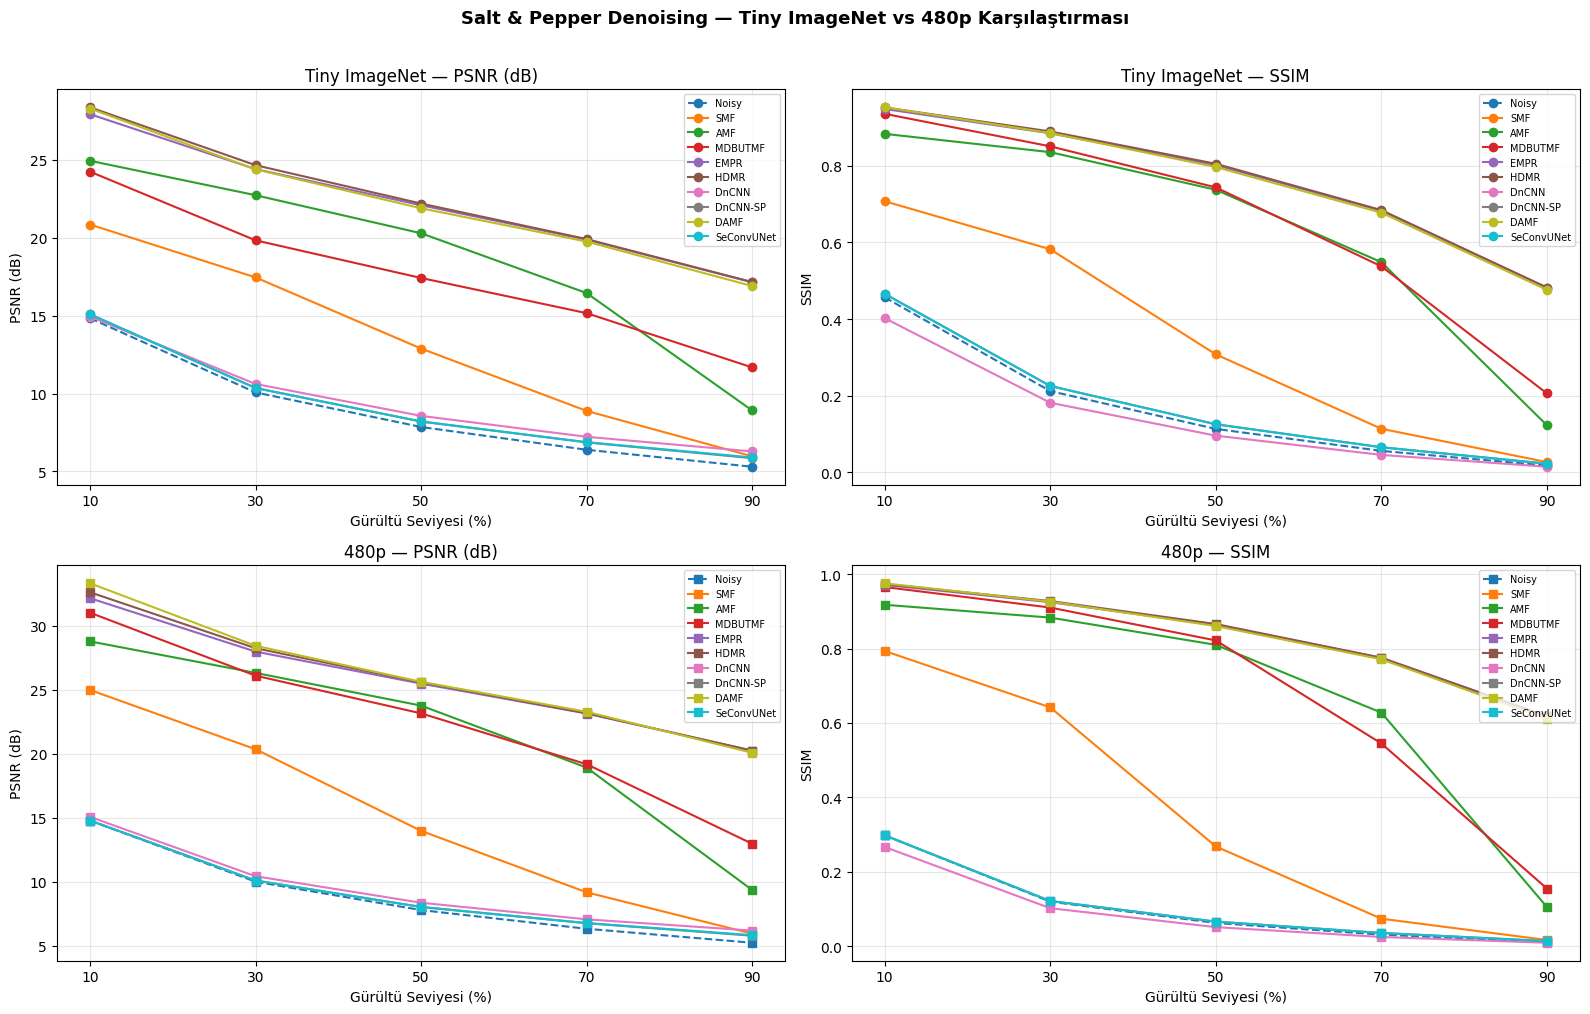

Grafik kaydedildi: psnr_ssim_comparison.pdf / .png


In [12]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    colors = cm.tab10.colors
    methods_list = list(TINY_METHODS.keys())

    for idx, method in enumerate(methods_list):
        c  = colors[idx % len(colors)]
        ls = '--' if method == 'Noisy' else '-'

        def vals(records, key):
            return [records[method][lv][key] if records[method][lv] else float('nan')
                    for lv in NOISE_LEVELS]

        axes[0,0].plot(NOISE_LEVELS, vals(records_tiny,'psnr'), marker='o',
                       label=method, color=c, linestyle=ls)
        axes[0,1].plot(NOISE_LEVELS, vals(records_tiny,'ssim'), marker='o',
                       label=method, color=c, linestyle=ls)
        if any(records_480p[method][lv] for lv in NOISE_LEVELS):
            axes[1,0].plot(NOISE_LEVELS, vals(records_480p,'psnr'), marker='s',
                           label=method, color=c, linestyle=ls)
            axes[1,1].plot(NOISE_LEVELS, vals(records_480p,'ssim'), marker='s',
                           label=method, color=c, linestyle=ls)

    titles = [
        ('Tiny ImageNet — PSNR (dB)', 'PSNR (dB)'),
        ('Tiny ImageNet — SSIM',      'SSIM'),
        ('480p — PSNR (dB)',          'PSNR (dB)'),
        ('480p — SSIM',               'SSIM'),
    ]
    for ax, (title, ylabel) in zip(axes.flat, titles):
        ax.set(xlabel='Gürültü Seviyesi (%)', ylabel=ylabel,
               title=title, xticks=NOISE_LEVELS)
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Salt & Pepper Denoising — Tiny ImageNet vs 480p Karşılaştırması',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('psnr_ssim_comparison.pdf', dpi=150, bbox_inches='tight')
    plt.savefig('psnr_ssim_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Grafik kaydedildi: psnr_ssim_comparison.pdf / .png')
except ImportError:
    print('matplotlib yüklü değil.')
